In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandocfilters import Null
from statsmodels.miscmodels import count

In [2]:
df = pd.read_csv("aws_supply_chain_orders_raw.csv")

In [3]:
df.head()

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,4.0,Pending
1,ORD-1001,WH-A,West,Laptop,30,2026-02-25 06:22:56.185905,2026-03-15 06:22:56.186205,12.0,Pending
2,ORD-1002,WH-C,South,Switch,19,2026-03-13 06:22:56.185910,2026-03-13 06:22:56.186207,13.0,Pending
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,9.0,Pending
4,ORD-1004,WH-A,East,Laptop,19,2026-02-18 06:22:56.185916,2026-03-11 06:22:56.186211,3.0,Delivered


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            155 non-null    object 
 1   warehouse           155 non-null    object 
 2   region              150 non-null    object 
 3   product             155 non-null    object 
 4   order_qty           155 non-null    int64  
 5   order_date          155 non-null    object 
 6   delivery_date       155 non-null    object 
 7   delivery_time_days  144 non-null    float64
 8   status              155 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 11.0+ KB


In [5]:
df.describe()

,order_qty,delivery_time_days
count,155.000000,144.000000
mean,26.025806,8.041667
std,13.606219,3.998033
min,1.000000,1.000000
25%,16.000000,5.000000
50%,26.000000,8.500000
75%,36.000000,12.000000
max,49.000000,14.000000


In [6]:
df.isnull().sum()

order_id               0
warehouse              0
region                 5
product                0
order_qty              0
order_date             0
delivery_date          0
delivery_time_days    11
status                 0
dtype: int64

In [7]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["delivery_date"] = pd.to_datetime(df["delivery_date"])

In [8]:
df["delivery_time_days"] = (df["delivery_date"] - df["order_date"]).dt.days

In [9]:
removed_rows = df[df.isna().any(axis=1)]

In [10]:
df.dropna(inplace=True)

In [11]:
df

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,36,Pending
1,ORD-1001,WH-A,West,Laptop,30,2026-02-25 06:22:56.185905,2026-03-15 06:22:56.186205,18,Pending
2,ORD-1002,WH-C,South,Switch,19,2026-03-13 06:22:56.185910,2026-03-13 06:22:56.186207,0,Pending
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,15,Pending
4,ORD-1004,WH-A,East,Laptop,19,2026-02-18 06:22:56.185916,2026-03-11 06:22:56.186211,21,Delivered
...,...,...,...,...,...,...,...,...,...
150,ORD-1101,WH-C,South,Router,29,2026-02-02 06:22:56.186094,2026-03-06 06:22:56.186381,32,Delivered
151,ORD-1082,WH-B,North,Laptop,12,2026-01-29 06:22:56.186062,2026-03-05 06:22:56.186350,35,Delivered
152,ORD-1031,WH-C,South,Server,37,2026-03-05 06:22:56.185974,2026-03-05 06:22:56.186259,0,Delivered
153,ORD-1064,WH-B,South,Laptop,45,2026-02-06 06:22:56.186031,2026-03-05 06:22:56.186321,27,Delivered


In [12]:
removed_rows

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status
49,ORD-1049,WH-B,NaN,Server,36,2026-03-17 06:22:56.186005,2026-03-16 06:22:56.186296,-1,Delivered
52,ORD-1052,WH-B,NaN,Laptop,37,2026-02-19 06:22:56.186010,2026-03-06 06:22:56.186301,15,Delayed
57,ORD-1057,WH-A,NaN,Switch,34,2026-02-07 06:22:56.186019,2026-02-22 06:22:56.186309,15,Pending
99,ORD-1099,WH-A,NaN,Switch,26,2026-01-28 06:22:56.186091,2026-02-28 06:22:56.186378,31,Pending
147,ORD-1147,WH-C,NaN,Switch,13,2026-02-20 06:22:56.186174,2026-03-08 06:22:56.186460,16,Pending


In [13]:
df.columns

Index(['order_id', 'warehouse', 'region', 'product', 'order_qty', 'order_date',
       'delivery_date', 'delivery_time_days', 'status'],
      dtype='object')

In [14]:
df.duplicated().sum()

5

In [47]:
df['delivery_time_days'] = abs(df['delivery_time_days'])

In [48]:
df[df.duplicated()==True]

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,region_encoded,product_encoded,warehouse_encoded
150,ORD-1101,WH-C,South,Router,29,2026-02-02 06:22:56.186094,2026-03-06 06:22:56.186381,32,Delivered,2,1,2
151,ORD-1082,WH-B,North,Laptop,12,2026-01-29 06:22:56.186062,2026-03-05 06:22:56.186350,35,Delivered,1,0,1
152,ORD-1031,WH-C,South,Server,37,2026-03-05 06:22:56.185974,2026-03-05 06:22:56.186259,0,Delivered,2,2,2
153,ORD-1064,WH-B,South,Laptop,45,2026-02-06 06:22:56.186031,2026-03-05 06:22:56.186321,27,Delivered,2,0,1
154,ORD-1067,WH-B,West,Storage,24,2026-03-17 06:22:56.186036,2026-02-26 06:22:56.186326,19,Delivered,3,3,1


([<matplotlib.patches.Wedge at 0x26473ab7a00>,
 [Text(0.33991867422268784, 1.0461621742897658, 'Delivered'),
  Text(-1.0048999726878363, -0.4474103763794331, 'Pending'),
  Text(0.7360437843500347, -0.8174592023579401, 'Delayed')],
 [Text(0.1854101859396479, 0.5706339132489631, '40.0%'),
  Text(-0.5481272578297288, -0.24404202347969076, '33.3%'),
  Text(0.4014784278272916, -0.4458868376497855, '26.7%')])

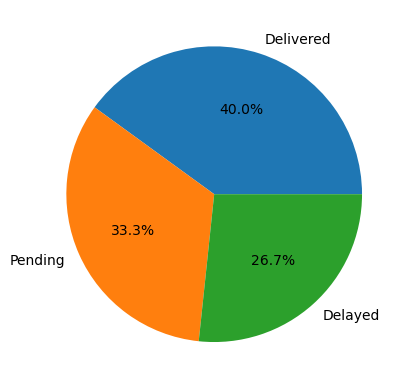

In [49]:
plt.pie(df["status"].value_counts(), labels=df["status"].value_counts().index, autopct="%1.1f%%")

([<matplotlib.patches.Wedge at 0x264733e6070>,
 [Text(0.4049370232742902, 1.0227541284110062, 'WH-C'),
  Text(-1.0709368013132876, -0.25118592236203036, 'WH-B'),
  Text(0.6277849086665324, -0.9032641410188682, 'WH-A')],
 [Text(0.22087473996779464, 0.5578658882241851, '38.0%'),
  Text(-0.5841473461708842, -0.13701050310656201, '31.3%'),
  Text(0.34242813199992667, -0.4926895314648371, '30.7%')])

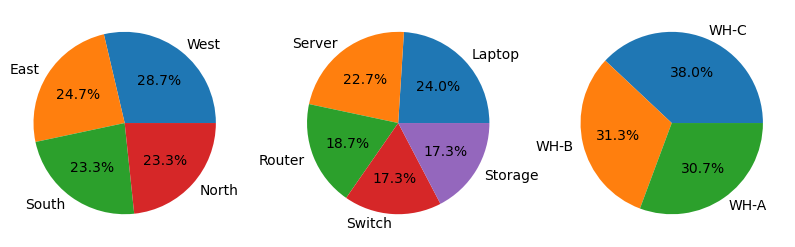

In [50]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 3, 1)
plt.pie(df["region"].value_counts(), labels=df["region"].value_counts().index, autopct="%1.1f%%")
plt.subplot(1, 3, 2)
plt.pie(df["product"].value_counts(), labels=df["product"].value_counts().index, autopct="%1.1f%%")
plt.subplot(1, 3, 3)
plt.pie(df["warehouse"].value_counts(), labels=df["warehouse"].value_counts().index, autopct="%1.1f%%")

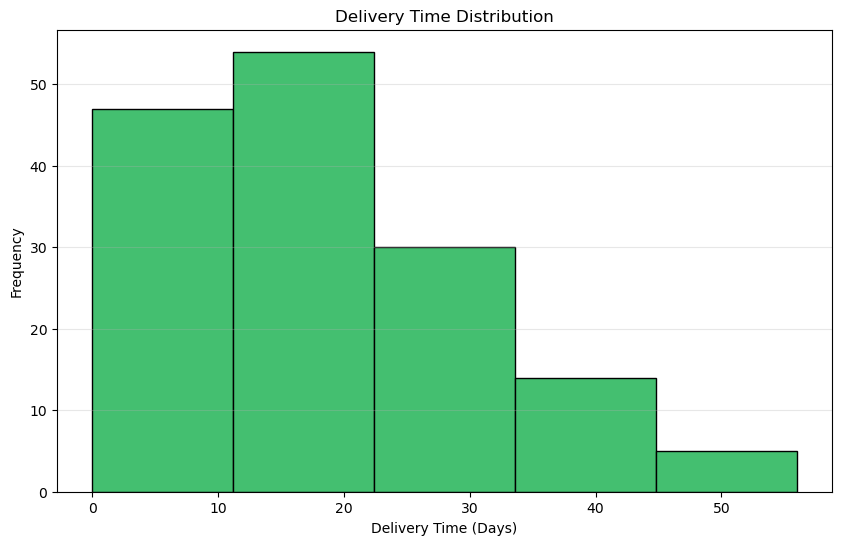

In [51]:
plt.figure(figsize=(10,6))
plt.hist(
    df["delivery_time_days"],
    bins=5,
    edgecolor='black',
    color=plt.cm.viridis(0.7)
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")
plt.title("Delivery Time Distribution")

plt.grid(axis='y', alpha=0.3)
plt.show()

In [52]:
df.dtypes

order_id                      object
warehouse                     object
region                        object
product                       object
order_qty                      int64
order_date            datetime64[ns]
delivery_date         datetime64[ns]
delivery_time_days             int64
status                        object
region_encoded                  int8
product_encoded                 int8
warehouse_encoded               int8
dtype: object

In [53]:
df

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,region_encoded,product_encoded,warehouse_encoded
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,36,Pending,3,1,2
1,ORD-1001,WH-A,West,Laptop,30,2026-02-25 06:22:56.185905,2026-03-15 06:22:56.186205,18,Pending,3,0,0
2,ORD-1002,WH-C,South,Switch,19,2026-03-13 06:22:56.185910,2026-03-13 06:22:56.186207,0,Pending,2,4,2
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,15,Pending,1,2,2
4,ORD-1004,WH-A,East,Laptop,19,2026-02-18 06:22:56.185916,2026-03-11 06:22:56.186211,21,Delivered,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
150,ORD-1101,WH-C,South,Router,29,2026-02-02 06:22:56.186094,2026-03-06 06:22:56.186381,32,Delivered,2,1,2
151,ORD-1082,WH-B,North,Laptop,12,2026-01-29 06:22:56.186062,2026-03-05 06:22:56.186350,35,Delivered,1,0,1
152,ORD-1031,WH-C,South,Server,37,2026-03-05 06:22:56.185974,2026-03-05 06:22:56.186259,0,Delivered,2,2,2
153,ORD-1064,WH-B,South,Laptop,45,2026-02-06 06:22:56.186031,2026-03-05 06:22:56.186321,27,Delivered,2,0,1


In [54]:
df['region_encoded'] = (
    df['region']
    .astype('category')
    .cat.codes
)

In [55]:
df['product_encoded'] = (
    df['product']
    .astype('category')
    .cat.codes
)

In [56]:
df['warehouse_encoded'] = (
    df['warehouse']
    .astype('category')
    .cat.codes
)

In [57]:
df

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,region_encoded,product_encoded,warehouse_encoded
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,36,Pending,3,1,2
1,ORD-1001,WH-A,West,Laptop,30,2026-02-25 06:22:56.185905,2026-03-15 06:22:56.186205,18,Pending,3,0,0
2,ORD-1002,WH-C,South,Switch,19,2026-03-13 06:22:56.185910,2026-03-13 06:22:56.186207,0,Pending,2,4,2
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,15,Pending,1,2,2
4,ORD-1004,WH-A,East,Laptop,19,2026-02-18 06:22:56.185916,2026-03-11 06:22:56.186211,21,Delivered,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
150,ORD-1101,WH-C,South,Router,29,2026-02-02 06:22:56.186094,2026-03-06 06:22:56.186381,32,Delivered,2,1,2
151,ORD-1082,WH-B,North,Laptop,12,2026-01-29 06:22:56.186062,2026-03-05 06:22:56.186350,35,Delivered,1,0,1
152,ORD-1031,WH-C,South,Server,37,2026-03-05 06:22:56.185974,2026-03-05 06:22:56.186259,0,Delivered,2,2,2
153,ORD-1064,WH-B,South,Laptop,45,2026-02-06 06:22:56.186031,2026-03-05 06:22:56.186321,27,Delivered,2,0,1


<Axes: xlabel='delivery_time_days'>

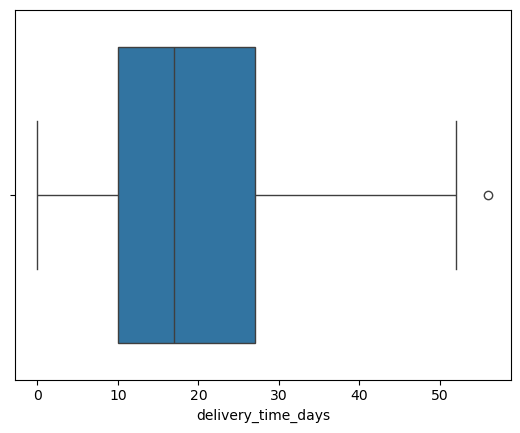

In [58]:
sns.boxplot(x=df["delivery_time_days"])

In [59]:
df.dtypes

order_id                      object
warehouse                     object
region                        object
product                       object
order_qty                      int64
order_date            datetime64[ns]
delivery_date         datetime64[ns]
delivery_time_days             int64
status                        object
region_encoded                  int8
product_encoded                 int8
warehouse_encoded               int8
dtype: object

In [60]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

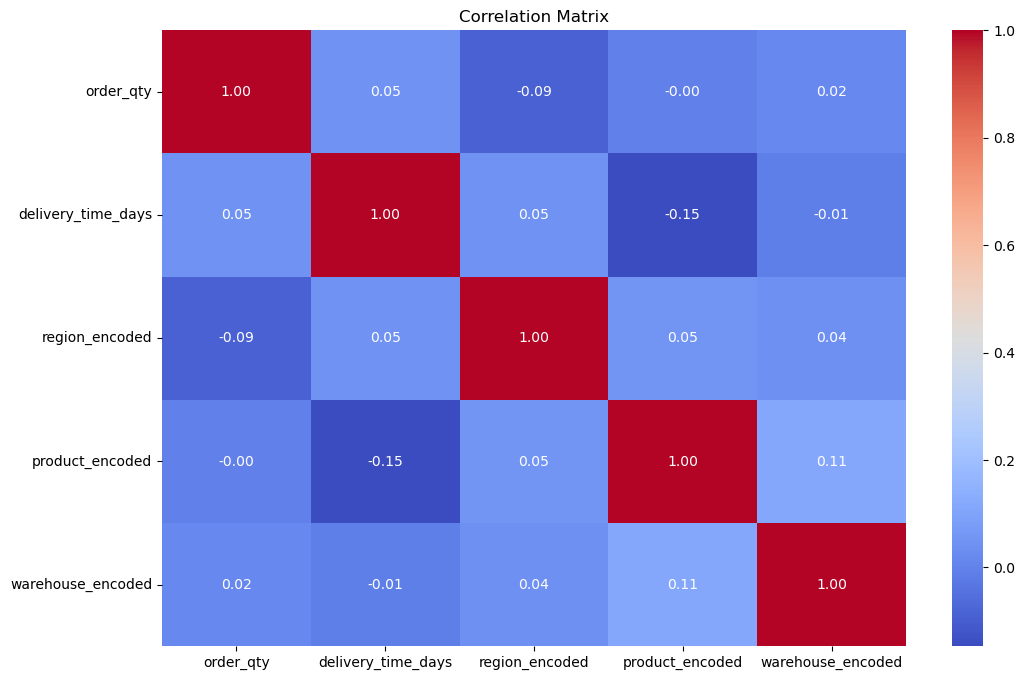

In [61]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

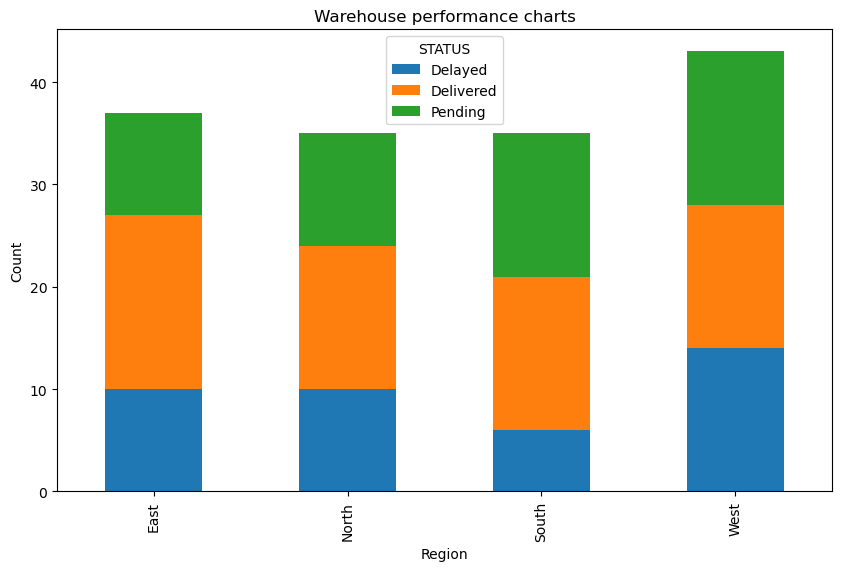

In [65]:
pivot = pd.crosstab(
    df['region'],
    df['status']
)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Region")
plt.ylabel("Count")
plt.title("Warehouse performance charts")
plt.legend(title='STATUS')

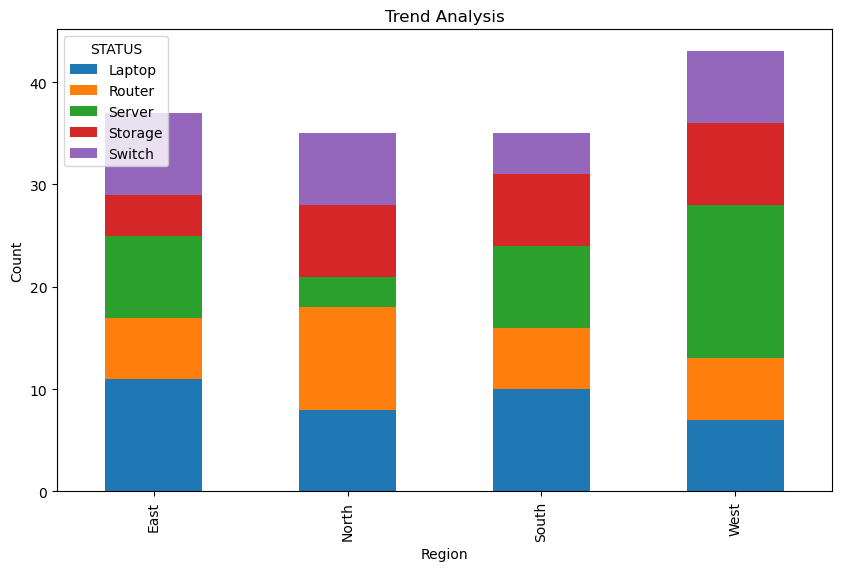

In [66]:
pivot = pd.crosstab(
    df['region'],
    df['product']
)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Region")
plt.ylabel("Count")
plt.title("Trend Analysis")
plt.legend(title='STATUS')

Text(0.5, 1.0, 'On-time vs delayed scatter plots')

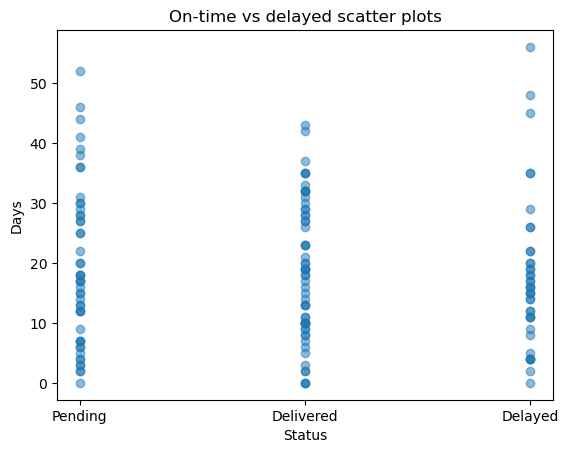

In [75]:
plt.scatter(
    df['status'],
    df['delivery_time_days'],
alpha=0.5,)
plt.xlabel("Status")
plt.ylabel("Days")
plt.title("On-time vs delayed scatter plots")

Text(0.5, 1.0, 'Product-Level Sales Heatmap')

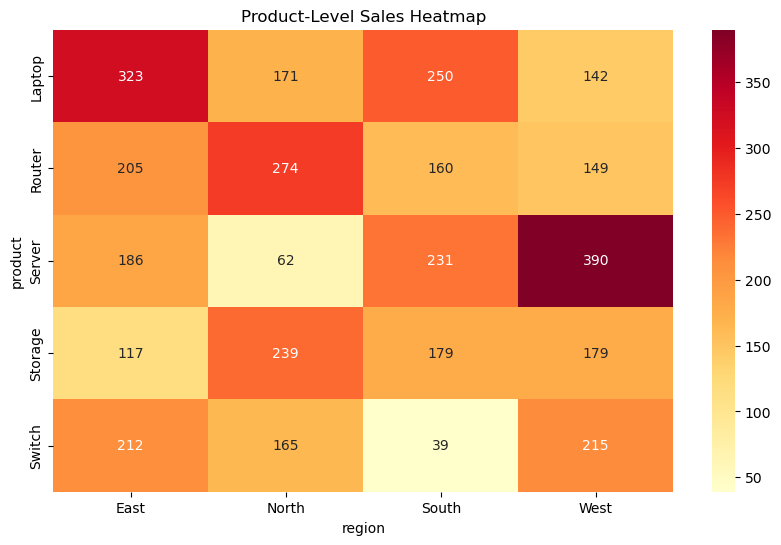

In [77]:
pivot = df.pivot_table(
    values='order_qty',
    index='product',
    columns='region',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrRd',
    fmt='.0f'
)
plt.title("Product-Level Sales Heatmap")